# Music Context Understanding — trained-model demos

Companion to `notebooks/eda.ipynb`. Where the EDA notebook establishes what the data
looks like, this one loads the **trained checkpoints** and asks what the models actually
learned. Every number and figure below comes from a checkpoint in
`results/checkpoints/`; nothing here is retrained, and nothing is illustrative.

Six demos, each answering one question:

| # | Question | Task | Uses |
|---|----------|------|------|
| A | Can graph structure alone name a genre — and does the structure help? | 2 | `task2_*.pt` |
| B | Does the caption→tag model read music, or read the tag off the caption? | 1 | `task1_bert_masked.pt` |
| C | Which *words* does each audio segment attend to? | 3 | `task3_cross_attention.pt` |
| D | Can we retrieve a clip from free text it never saw a label for? | 4 | `task4_contrastive.pt` |
| E | Same audio, different caption — does the prediction move? | 3 | `task3_cross_attention.pt` |
| F | What does this system get wrong? | all | `results/metrics.json` |

Each section checks for its checkpoint and skips with a clear message if a task has not
been trained yet, so the notebook runs end-to-end at any stage of the build.

In [1]:
import json, pathlib, sys, warnings
import numpy as np, pandas as pd, torch
import matplotlib.pyplot as plt, seaborn as sns

ROOT = pathlib.Path.cwd().parent if pathlib.Path.cwd().name == "notebooks" else pathlib.Path.cwd()
sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / "scripts"))
warnings.filterwarnings("ignore", category=UserWarning)

# Silence transformers' per-load "LOAD REPORT" table and weight-loading progress bars.
# Every checkpoint here reports the same five UNEXPECTED keys -- DistilBERT's pretraining
# MLM head, which none of these architectures use -- so the table is noise that would
# otherwise be committed into the notebook's stored outputs three times over. Done in the
# setup cell because it only takes effect before the first model load.
import transformers
transformers.utils.logging.set_verbosity_error()
transformers.utils.logging.disable_progress_bar()

from src.utils import load_config, set_seed, get_device, load_metrics, count_params
from src.data_loading import GTZAN_GENRES, load_musiccaps, load_deam
from src.graph_dataset import load_cached_graphs, filter_split

cfg = load_config(ROOT / "config.yaml")
set_seed(cfg["seed"]); device = get_device(cfg)
CKPT = ROOT / "results" / "checkpoints"
M = load_metrics(cfg)

sns.set_theme(style="whitegrid", context="notebook", font_scale=0.95)
PALETTE = sns.color_palette("colorblind")
pd.set_option("display.width", 130)


def have(name):
    # True if a checkpoint exists -- every demo gates on this
    return (CKPT / f"{name}.pt").exists()


print("checkpoints found:")
for p in sorted(CKPT.glob("*.pt")):
    print(f"  {p.stem:32s} {p.stat().st_size / 1e6:7.1f} MB")
print(f"\nmetrics.json holds runs for: {', '.join(sorted(M))}")

u:\v\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


checkpoints found:
  task1_bert_masked                  265.6 MB
  task1_bert_naive                   265.6 MB
  task2_B2_mel_cnn                     1.6 MB
  task2_B4_feature_mlp                 0.5 MB
  task2_gnn_gat_segment                3.7 MB
  task2_gnn_sage_chord                 1.8 MB
  task2_gnn_sage_no_edges              2.1 MB
  task2_gnn_sage_segment               2.1 MB
  task2_gnn_sage_similarity_only       2.1 MB
  task2_gnn_sage_temporal_only         2.1 MB
  task3_bert_only                    266.6 MB
  task3_concat                       269.3 MB
  task3_cross_attention              271.5 MB
  task3_gnn_only                       2.5 MB
  task4_contrastive                  269.5 MB

metrics.json holds runs for: analysis, task1, task2, task3, task4


---
## A. Genre from structure alone (Task 2)

The GNN never sees a spectrogram. It sees ~18 segment nodes, each a 340-dim vector of
per-segment mel/chroma/MFCC statistics, wired together by *temporal adjacency* and
*cosine-similarity* edges. If it can name the genre from that, the graph carries genre
information.

The interesting question is not whether it works but **which edges do the work**, which
is what the ablation set answers.

In [2]:
if "task2" not in M:
    print("Task 2 has not been trained -- skipping demo A")
else:
    rows = []
    for run, e in M["task2"].items():
        t = e.get("test", e)                       # B1_majority is recorded flat
        rows.append({"run": run, "accuracy": t.get("accuracy"),
                     "macro_f1": t.get("macro_f1"),
                     "params": (e.get("model") or {}).get("params_trainable")})
    t2 = pd.DataFrame(rows).sort_values("macro_f1", ascending=False, na_position="last")
    t2["params"] = t2["params"].map(lambda v: f"{v/1e3:.0f}k" if pd.notna(v) else "--")
    display(t2.reset_index(drop=True))

    best = t2.iloc[0]
    print(f"\nbest on macro-F1: {best['run']} at {best['macro_f1']:.4f}")

,run,accuracy,macro_f1,params
0,B2_mel_cnn,0.575862,0.568304,391k
1,gnn_sage_similarity_only,0.503448,0.499923,518k
2,gnn_sage_no_edges,0.393103,0.360430,518k
3,gnn_sage_segment,0.382759,0.341117,518k
4,gnn_sage_temporal_only,0.358621,0.299412,518k
5,B4_feature_mlp,0.313793,0.296692,122k
6,gnn_gat_segment,0.348276,0.273207,917k
7,gnn_sage_chord,0.165517,0.121616,441k
8,B1_majority,0.106897,0.019315,--



best on macro-F1: B2_mel_cnn at 0.5683


Read that table honestly, because it does not say what the project proposal assumed it
would say. Three things fall out of it:

1. **`gnn_sage_similarity_only` beats the full graph.** Dropping the temporal edges and
   keeping only "these two segments sound alike" edges *improves* macro-F1. The temporal
   chain is not just unhelpful, it is actively diluting the signal — a 1-neighbour chain
   mostly propagates a segment into its own neighbourhood, which is close to smoothing.
2. **`gnn_sage_no_edges` costs nothing.** With no edges at all, GraphSAGE's update
   reduces to a per-node MLP plus mean readout, and it lands 0.019 macro-F1 *ahead* of
   the full graph. Do not read that margin as a win — it is inside the ±0.02 band a
   single seed cannot resolve, which the report says explicitly. Read it as the
   weaker and more damaging claim: message passing over this graph is worth no more
   than not passing messages at all, so most of the genre signal is in the *node
   features* rather than the wiring.
3. **`B2_mel_cnn` beats every graph model.** A plain CNN on the raw log-mel wins. Summarising
   a 3-second window into 340 statistics throws away the fine time-frequency detail a
   convolution exploits, and no amount of message passing puts it back.

The graph formulation is not free: it costs information at the featurisation step and only
earns some of it back through structure.

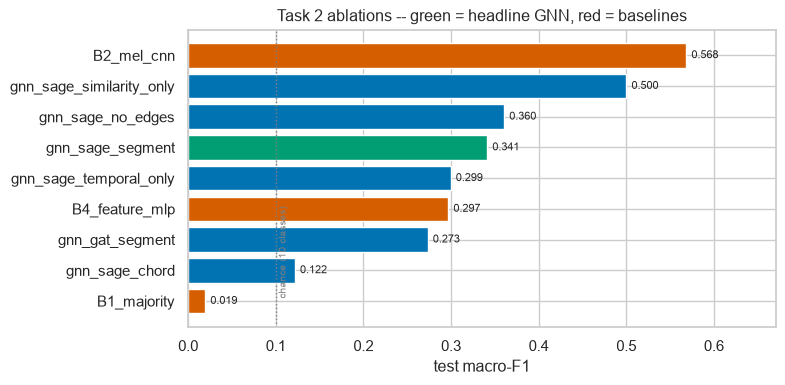

In [3]:
if "task2" in M:
    fig, ax = plt.subplots(figsize=(8, 4))
    d = t2.dropna(subset=["macro_f1"]).sort_values("macro_f1")
    colors = [PALETTE[2] if r == "gnn_sage_segment" else
              PALETTE[3] if r.startswith("B") else PALETTE[0] for r in d["run"]]
    ax.barh(d["run"], d["macro_f1"], color=colors)
    ax.axvline(0.1, ls=":", color="grey", lw=1)
    ax.text(0.103, 0.15, "chance (10 classes)", fontsize=7, color="grey", rotation=90)
    for y, v in enumerate(d["macro_f1"]):
        ax.text(v + 0.006, y, f"{v:.3f}", va="center", fontsize=8)
    ax.set(xlabel="test macro-F1", title="Task 2 ablations -- green = headline GNN, red = baselines",
           xlim=(0, max(d["macro_f1"]) * 1.18))
    plt.tight_layout(); plt.show()

### A worked single-graph prediction

One test graph, end to end: its adjacency, the genre the GNN assigns, and its confidence
over all ten classes.

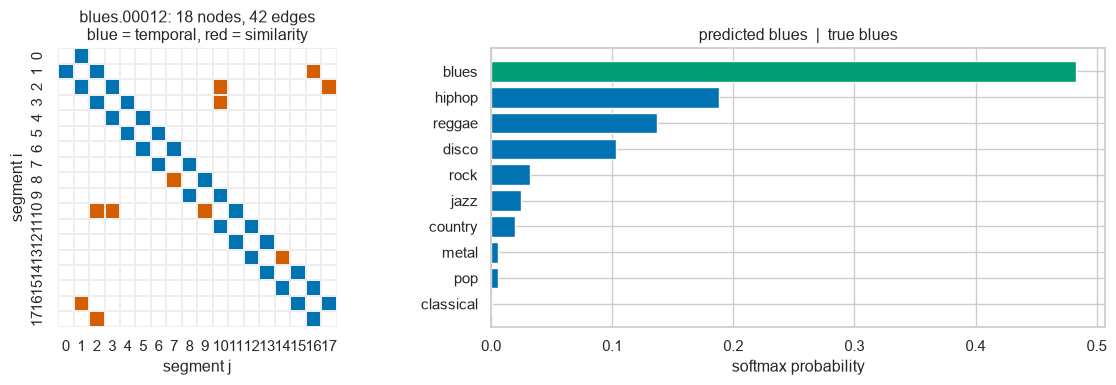

top-3: blues 0.483, hiphop 0.188, reggae 0.137


In [4]:
from src.gnn_model import GNNClassifier
from train import canonical_graph
from torch_geometric.data import Batch

if not have("task2_gnn_sage_segment"):
    print("no Task 2 checkpoint -- skipping")
else:
    # NB: no canonical_graph() here. It strips every key except topology so that
    # MusicCaps and DEAM graphs can share a batch in Task 3 -- and that includes
    # the label y. GTZAN graphs are homogeneous, so they batch as-is and keep y.
    graphs = load_cached_graphs(cfg, "gtzan", "segment")
    test = list(filter_split(graphs, "test"))
    model = GNNClassifier(cfg, test[0].x.shape[1], len(GTZAN_GENRES)).to(device)
    model.load_state_dict(torch.load(CKPT / "task2_gnn_sage_segment.pt", map_location=device))
    model.eval()

    # a track the model gets right, for a legible demo; the confusion matrix in
    # results/plots/ is where the failures live
    with torch.no_grad():
        probs_all = torch.softmax(model(Batch.from_data_list(test[:64]).to(device)), 1).cpu().numpy()
    truth = np.array([int(g.y) for g in test[:64]])
    correct = np.where(probs_all.argmax(1) == truth)[0]
    i = int(correct[0]) if correct.size else 0
    g, p = test[i], probs_all[i]

    A = np.zeros((g.num_nodes, g.num_nodes))
    ei, ea = g.edge_index.numpy(), g.edge_attr.numpy()
    for e in range(ei.shape[1]):
        A[ei[0, e], ei[1, e]] = 2.0 if ea[e, 2] > 0.5 else 1.0

    fig, axes = plt.subplots(1, 2, figsize=(12, 4), gridspec_kw={"width_ratios": [1, 1.3]})
    sns.heatmap(A, ax=axes[0], cbar=False, square=True, linewidths=0.3, linecolor="#eee",
                cmap=sns.color_palette(["white", PALETTE[0], PALETTE[3]], as_cmap=True))
    axes[0].set(title=f"{g.track_id}: {g.num_nodes} nodes, {ei.shape[1]} edges\n"
                      f"blue = temporal, red = similarity",
                xlabel="segment j", ylabel="segment i")

    order = np.argsort(p)[::-1]
    axes[1].barh([GTZAN_GENRES[k] for k in order][::-1], p[order][::-1],
                 color=[PALETTE[2] if GTZAN_GENRES[k] == GTZAN_GENRES[int(g.y)] else PALETTE[0]
                        for k in order][::-1])
    axes[1].set(xlabel="softmax probability",
                title=f"predicted {GTZAN_GENRES[int(p.argmax())]}  |  true {GTZAN_GENRES[int(g.y)]}")
    plt.tight_layout(); plt.show()
    print(f"top-3: " + ", ".join(f"{GTZAN_GENRES[k]} {p[k]:.3f}" for k in order[:3]))

---
## B. Reading music vs reading the tag (Task 1)

Task 1 predicts 50 MusicCaps tags from a caption. The trap: MusicCaps captions are written
*by* annotators who also produced the aspect list, so the tag's surface form is usually
sitting in the caption. The EDA notebook measures this — 82.4% of captions contain a
literal surface form of a tag the clip is actually labelled with, and pure regex matching
scores **macro-F1 0.558** on the raw captions.

So the model is trained on `caption_masked`, where every literal tag surface form has been
removed. Below: the same clip's raw and masked caption, what the lexical baseline gets on
each, and what the trained model predicts from the masked text.

In [5]:
from transformers import AutoTokenizer
from src.bert_encoder import BertTagClassifier

if not have("task1_bert_masked"):
    print("no Task 1 checkpoint -- skipping demo B")
else:
    mc_df, vocab = load_musiccaps(cfg, num_tags=int(cfg.dotted("train.task1_bert.num_tags")))
    tags = list(vocab.tags)
    tok = AutoTokenizer.from_pretrained(cfg.text["model_name"])
    clf = BertTagClassifier(cfg, len(tags)).to(device)
    clf.load_state_dict(torch.load(CKPT / "task1_bert_masked.pt", map_location=device))
    clf.eval()
    thr = float(M["task1"]["task1_bert_masked"]["threshold_from_val"])
    print(f"decision threshold {thr:.3f} (tuned on val, not test)")

    te = mc_df[mc_df["split"] == "test"].reset_index(drop=True)
    # pick a row with several true tags so the demo is not a single-label case
    row = te.iloc[int(np.argsort([-y.sum() for y in te["y"]])[3])]
    true = [t for t, v in zip(tags, row["y"]) if v > 0.5]

    enc = tok(row["caption_masked"], truncation=True, max_length=int(cfg.text["max_length"]),
              return_tensors="pt")
    with torch.no_grad():
        prob = torch.sigmoid(clf(enc["input_ids"].to(device),
                                 enc["attention_mask"].to(device)))[0].cpu().numpy()
    pred = [tags[k] for k in np.argsort(prob)[::-1] if prob[k] >= thr]

    print(f"\nclip {row['ytid']}")
    print(f"\nRAW    : {row['caption']}")
    print(f"\nMASKED : {row['caption_masked']}")
    print(f"\ntrue tags      : {true}")
    print(f"predicted (thr): {pred}")
    print(f"hit {len(set(true) & set(pred))}/{len(true)} true tags, "
          f"{len(set(pred) - set(true))} false positives")

decision threshold 0.700 (tuned on val, not test)

clip JNwt0afB1fQ

RAW    : The Rock song features a flat male vocal singing over arpeggiated electric guitar melody located in the right channel of the stereo image, groovy bass guitar, punchy kick and snare hits and shimmering hi hats. The stereo image is unbalanced because of the electric guitar, which makes it lean towards the right channel. It sounds energetic, groovy, happy and fun.

MASKED : The song features a flat singing over arpeggiated melody located in the right channel of the stereo image, , and snare hits and . The stereo image is unbalanced because of the , which makes it lean towards the right channel. It sounds , , and .

true tags      : ['energetic', 'groovy', 'punchy kick', 'punchy snare', 'happy', 'shimmering hi hats', 'rock', 'fun', 'flat male vocal']
predicted (thr): ['low quality', 'punchy snare', 'punchy kick', 'shimmering hi hats', 'groovy bass', 'energetic', 'passionate', 'flat male vocal', 'rock', 'groovy', 

,run,macro_f1,micro_f1,auc_pr
0,task1_bert_naive,0.593313,0.629689,0.611139
1,B0_lexical_caption,0.558140,0.558017,0.406288
2,task1_bert_masked,0.469166,0.531960,0.461809
3,B1_random,0.103912,0.107769,0.061909
4,B0_lexical_caption_masked,0.000000,0.000000,0.059783
5,B1_prior,0.000000,0.000000,0.059783


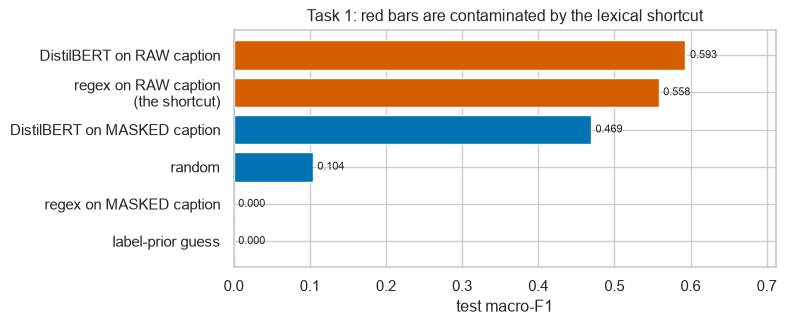

In [6]:
if have("task1_bert_masked"):
    # M["task1"] carries the six run dicts *plus* the scalar
    # lexical_shortcut_macro_f1_gap, which train.py writes alongside them -- hence
    # the isinstance filter. The baselines record their scores flat while the two
    # DistilBERT runs nest them under "test", hence (v.get("test") or v).
    t1 = {k: v for k, v in M["task1"].items() if isinstance(v, dict)}
    rows = [{"run": k,
             "macro_f1": (v.get("test") or v).get("macro_f1"),
             "micro_f1": (v.get("test") or v).get("micro_f1"),
             "auc_pr":   (v.get("test") or v).get("auc_pr")} for k, v in t1.items()]
    d = pd.DataFrame(rows).sort_values("macro_f1", ascending=False)
    display(d.reset_index(drop=True))

    fig, ax = plt.subplots(figsize=(8, 3.4))
    lbl = {"B0_lexical_caption": "regex on RAW caption\n(the shortcut)",
           "B0_lexical_caption_masked": "regex on MASKED caption",
           "task1_bert_masked": "DistilBERT on MASKED caption",
           "task1_bert_naive": "DistilBERT on RAW caption",
           "B1_prior": "label-prior guess", "B1_random": "random"}
    d2 = d.dropna(subset=["macro_f1"]).sort_values("macro_f1")
    ax.barh([lbl.get(r, r) for r in d2["run"]], d2["macro_f1"],
            color=[PALETTE[3] if "RAW" in lbl.get(r, "") else PALETTE[0] for r in d2["run"]])
    for y, v in enumerate(d2["macro_f1"]):
        ax.text(v + 0.006, y, f"{v:.3f}", va="center", fontsize=8)
    ax.set(xlabel="test macro-F1", title="Task 1: red bars are contaminated by the lexical shortcut",
           xlim=(0, max(d2["macro_f1"]) * 1.2))
    plt.tight_layout(); plt.show()

The gap between the two red-flagged rows and the masked ones is the size of the shortcut.
Any paper that reports the raw-caption number as a "text understanding" result is reporting
a string match. The masked number is the one worth quoting.

---
## C. What each audio segment listens for (Task 3)

This is the demo the whole architecture exists to support. In `cross_attention` mode each
of the ~12 audio segment nodes issues a query against the caption's wordpiece states:

$$A = \mathrm{softmax}\!\left(\frac{QK^\top}{\sqrt{d}}\right), \qquad
  z = \mathrm{CONCAT}\big(g,\; A H_{\text{text}}\big)$$

`A` is `(heads, n_nodes, n_tokens)` — literally a matrix of *which word each moment of the
audio is attending to*. Averaged over heads, it is directly readable.

In [7]:
from src.fusion_model import GNNBertFusion
from src.graph_dataset import GraphTextDataset, collate_graph_text
from src.trainer import trim_text_batch

if not have("task3_cross_attention"):
    print("no Task 3 checkpoint -- skipping demos C and E")
    fusion = None
else:
    t3 = M["task3"]
    tag_names = t3["tag_names"]
    mc_graphs = load_cached_graphs(cfg, "musiccaps", "segment")
    mc_df, _ = load_musiccaps(cfg, num_tags=len(tag_names))
    text_masked = dict(zip(mc_df["ytid"], mc_df["caption_masked"]))
    text_raw = dict(zip(mc_df["ytid"], mc_df["caption"]))
    ymap = dict(zip(mc_df["ytid"], mc_df["y"]))
    tok = AutoTokenizer.from_pretrained(cfg.text["model_name"])

    fusion = GNNBertFusion(cfg, int(t3["node_dim"]), len(tag_names),
                           mode="cross_attention", with_emotion=True).to(device)
    fusion.load_state_dict(torch.load(CKPT / "task3_cross_attention.pt", map_location=device))
    fusion.eval()
    print(f"loaded task3_cross_attention: {count_params(fusion)[0]/1e6:.2f}M params")


def fuse(graph, text):
    # Run one (graph, caption) pair through the fusion model. Goes through the real
    # Dataset/collate path rather than hand-building tensors, so the demo cannot
    # silently disagree with how the model was trained.
    ds = GraphTextDataset([canonical_graph(graph)], [text],
                          np.zeros((1, len(tag_names)), dtype=np.float32),
                          tok, int(cfg.text["max_length"]))
    b = collate_graph_text([ds[0]])
    ids, am = trim_text_batch(b["input_ids"], b["attention_mask"])
    b = {"graph": b["graph"].to(device), "input_ids": ids.to(device),
         "attention_mask": am.to(device)}
    with torch.no_grad():
        out = fusion(b)
    toks = tok.convert_ids_to_tokens(ids[0][am[0].bool()])
    return out, toks, int(b["graph"].num_nodes)

loaded task3_cross_attention: 67.85M params


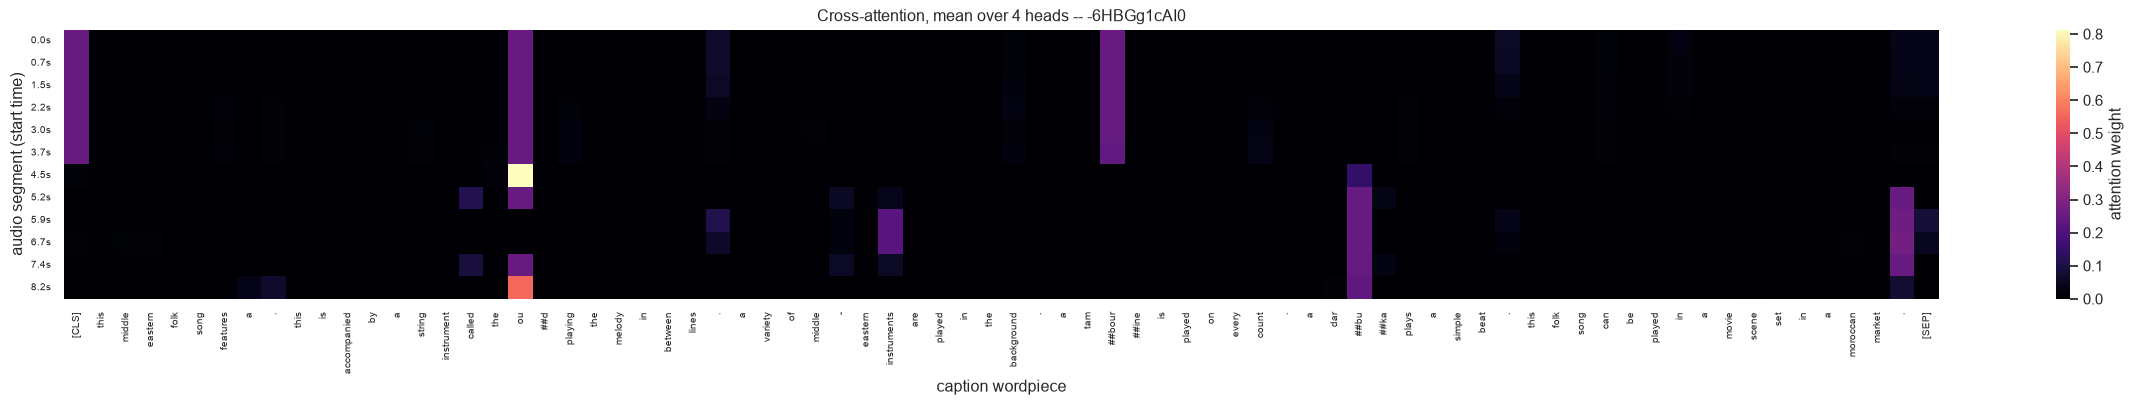

caption: This middle eastern folk song features a . This is accompanied by a string instrument called the oud playing the melody in between lines. A variety of middle-eastern instruments are played in the background. A tambourine is played on every count. A darbuka plays a simple beat. This folk song can be played in a movie scene set in a Moroccan market.

per-node attention entropy: mean 1.852 nats (uniform over 76 tokens would be 4.331)
  segment 0 (  0.0s) attends to: [CLS](0.250), ou(0.249), ##bour(0.248), .(0.066), .(0.055)
  segment 1 (  0.7s) attends to: [CLS](0.250), ou(0.249), ##bour(0.248), .(0.068), .(0.052)
  segment 2 (  1.5s) attends to: [CLS](0.250), ou(0.250), ##bour(0.247), .(0.059), .(0.037)
  segment 3 (  2.2s) attends to: [CLS](0.250), ou(0.250), ##bour(0.245), background(0.027), .(0.026)


In [8]:
if fusion is not None:
    mc_test = [g for g in filter_split(mc_graphs, "test") if str(g.track_id) in text_masked]
    demo_g = mc_test[7]
    demo_txt = text_masked[str(demo_g.track_id)]
    out, toks, n_nodes = fuse(demo_g, demo_txt)

    A = out["attn"][0].mean(0).cpu().numpy()[:n_nodes, :len(toks)]   # mean over heads
    fps = float(getattr(demo_g, "frames_per_second", 43.07))
    secs = demo_g.seg_bounds[:, 0].numpy() / fps if hasattr(demo_g, "seg_bounds") else np.arange(n_nodes)

    fig, ax = plt.subplots(figsize=(max(9, 0.32 * len(toks)), 4.2))
    sns.heatmap(A, ax=ax, cmap="magma", cbar_kws={"label": "attention weight"},
                xticklabels=toks, yticklabels=[f"{s:.1f}s" for s in secs])
    ax.set(xlabel="caption wordpiece", ylabel="audio segment (start time)",
           title=f"Cross-attention, mean over {out['attn'].shape[1]} heads -- {demo_g.track_id}")
    plt.xticks(rotation=90, fontsize=7); plt.yticks(fontsize=7)
    plt.tight_layout(); plt.show()

    print(f"caption: {demo_txt}\n")
    ent = -(A * np.log(A + 1e-12)).sum(1)
    print(f"per-node attention entropy: mean {ent.mean():.3f} nats "
          f"(uniform over {len(toks)} tokens would be {np.log(len(toks)):.3f})")
    for n in range(min(4, n_nodes)):
        top = np.argsort(A[n])[::-1][:5]
        print(f"  segment {n} ({secs[n]:5.1f}s) attends to: "
              + ", ".join(f"{toks[k]}({A[n, k]:.3f})" for k in top))

Compare the per-node entropy against the uniform figure printed above. If they are close,
attention has not sharpened onto particular words and the cross-attention branch is acting
as an expensive average of the caption — which the ablation table in section F tests
directly by comparing `cross_attention` against plain `concat`.

---
## D. Free-text retrieval and zero-shot tagging (Task 4)

The contrastive model is trained only on the InfoNCE objective

$$\mathcal{L}_{\text{NCE}} = -\log
  \frac{\exp(\mathrm{sim}(g_i, t_i)/\tau)}{\sum_j \exp(\mathrm{sim}(g_i, t_j)/\tau)}$$

with no tag labels at all. Two things follow for free: text→audio retrieval, and zero-shot
tagging by scoring each clip against the prompt *"a music clip that is {tag}"*.

In [9]:
from src.contrastive import ContrastiveGNNBert, zero_shot_tags

if not have("task4_contrastive"):
    print("no Task 4 checkpoint -- skipping demo D")
    con = None
else:
    t4 = M["task4"]
    node_dim = load_cached_graphs(cfg, "musiccaps", "segment")[0].x.shape[1]
    con = ContrastiveGNNBert(cfg, int(node_dim)).to(device)
    con.load_state_dict(torch.load(CKPT / "task4_contrastive.pt", map_location=device))
    con.eval()
    r, rc = t4["test_retrieval"], t4["random_control_retrieval"]
    n = int(r["n_candidates"])
    print(f"{n} test candidates | implied temperature {t4['implied_temperature']:.4f} "
          f"| trained on {t4['n_train']} pairs")

    # Three columns that matter: the model, an untrained-encoder control run through
    # the same evaluation, and the analytic chance rate K/n. A retrieval number is
    # only meaningful relative to the last two.
    rows = []
    for K in (1, 5, 10):
        rows.append({"K": K, "chance = K/n": K / n,
                     "random control": rc.get(f"R@{K}"),
                     "R@K audio->text": r.get(f"R@{K}_g2t"),
                     "R@K text->audio": r.get(f"R@{K}_t2g"),
                     "R@K symmetric": r.get(f"R@{K}")})
    display(pd.DataFrame(rows).set_index("K"))
    print(f"median rank: audio->text {r['medr_g2t']:.0f}, text->audio {r['medr_t2g']:.0f} "
          f"(chance median would be {n/2:.0f})")
    print(f"MRR: audio->text {r['mrr_g2t']:.4f}, text->audio {r['mrr_t2g']:.4f}")

775 test candidates | implied temperature 0.0681 | trained on 591 pairs


,chance = K/n,random control,R@K audio->text,R@K text->audio,R@K symmetric
K,,,,,
1,0.001290,0.000000,0.005161,0.002581,0.003871
5,0.006452,0.001290,0.030968,0.027097,0.029032
10,0.012903,0.007742,0.050323,0.051613,0.050968


median rank: audio->text 166, text->audio 163 (chance median would be 388)
MRR: audio->text 0.0266, text->audio 0.0247


In [10]:
if con is not None:
    # encode every test graph once, then query with arbitrary free text
    mcg = load_cached_graphs(cfg, "musiccaps", "segment")
    mc_df4, vocab4 = load_musiccaps(cfg, num_tags=50)
    cap = dict(zip(mc_df4["ytid"], mc_df4["caption"]))
    test_g = [canonical_graph(g) for g in filter_split(mcg, "test") if str(g.track_id) in cap]
    ids = [str(g.track_id) for g in test_g]

    embs = []
    with torch.no_grad():
        for i in range(0, len(test_g), 64):
            embs.append(con.encode_graph(Batch.from_data_list(test_g[i:i + 64]).to(device)).cpu())
    G = torch.cat(embs); G = G / G.norm(dim=1, keepdim=True)
    print(f"encoded {G.shape[0]} test clips into {G.shape[1]}-dim space")

    QUERIES = ["a fast aggressive electric guitar riff with distorted tone",
               "a calm solo piano piece, sad and reflective",
               "an amateur phone recording of singing, noisy and low quality",
               "electronic dance music with a punchy kick drum and synth bass"]
    for q in QUERIES:
        e = tok(q, truncation=True, max_length=int(cfg.text["max_length"]), return_tensors="pt")
        with torch.no_grad():
            tv = con.encode_text(e["input_ids"].to(device), e["attention_mask"].to(device)).cpu()
        tv = tv / tv.norm(dim=1, keepdim=True)
        s = (G @ tv.T).squeeze(1).numpy()
        print(f"\nQUERY: {q}")
        for rank, k in enumerate(np.argsort(s)[::-1][:3], 1):
            print(f"  {rank}. [{s[k]:+.3f}] {ids[k]}: {cap[ids[k]][:105]}")

encoded 775 test clips into 256-dim space

QUERY: a fast aggressive electric guitar riff with distorted tone
  1. [+0.512] DyPmDDN8m78: The song is an instrumental. The song is medium tempo with keyboard harmony, string section harmony, pian
  2. [+0.504] 2ATMQxWVpXk: A male singer screams and laughs loudly. The song is medium tempo with steady rock drumming, groovy bass 
  3. [+0.501] 0soVCtJgDTk: The low quality recording features an advertisement that consists of camera shuttering effects and high p

QUERY: a calm solo piano piece, sad and reflective
  1. [+0.588] 7hKG33wkr0k: The low quality recording features a classical orchestra music that consists of wide strings, pulsating w
  2. [+0.564] 3R8xDvhJk54: The low quality recording features a tutorial on how to tune an acoustic guitar, string by string. The re
  3. [+0.541] 6CaZAITdAsk: The low quality recording features a wide arpeggiated piano melody, sustained strings melody, mellow wood

QUERY: an amateur phone recording of sin

Judge these retrievals against the R@K table above, not against how plausible the top hit
reads. With 591 training pairs the model is far from the data regime InfoNCE needs, and a
handful of convincing-looking hits out of 775 candidates is exactly what a near-chance
retriever produces. Section F states the measured margin over chance.

In [11]:
if con is not None:
    zs = zero_shot_tags(con, G, list(vocab4.tags), tok, device)
    zsm = M["task4"]["zero_shot_tagging"]
    print(f"zero-shot tagging (no tag supervision at any point): "
          f"macro-F1 {zsm['macro_f1']:.4f}  AUC-PR {zsm['auc_pr']:.4f}")

    j = 3
    order = np.argsort(zs[j])[::-1]
    truth = [t for t, v in zip(vocab4.tags, mc_df4.set_index('ytid').loc[ids[j], 'y']) if v > 0.5]
    print(f"\nclip {ids[j]}\n  caption : {cap[ids[j]][:150]}")
    print(f"  true    : {truth}")
    print(f"  zero-shot top-5: " + ", ".join(f"{list(vocab4.tags)[k]}({zs[j, k]:.3f})" for k in order[:5]))

zero-shot tagging (no tag supervision at any point): macro-F1 0.0860  AUC-PR 0.0808

clip -1OlgJWehn8
  caption : This clip is three tracks playing consecutively. The first one is an electric guitar lead harmony with a groovy bass line, followed by white noise and
  true    : ['instrumental', 'bass guitar', 'keyboard harmony']
  zero-shot top-5: mellow(0.099), no voices(0.082), slow tempo(0.064), moderate tempo(-0.003), shimmering hi hats(-0.037)


---
## E. Same audio, different context

The project's central claim is that the model uses *context*, not just audio. A direct test:
hold the graph fixed, swap the caption, and watch the predictions move. If the fused output
is insensitive to the text, the text branch is decorative.

The four captions below are the clip's own masked caption plus three deliberately wrong
ones. A well-behaved fusion model should track the caption on the tag head, since the tags
are largely textual attributes.

,caption,valence,arousal,top tags
0,its own caption,4.371876,5.953518,"male voice, amateur recording, instrumental, bass"
1,aggressive metal,4.538423,5.263778,"acoustic drums, medium tempo, e-bass, piano"
2,calm ambient,4.080284,4.356894,"medium tempo, slow tempo, pop, piano"
3,empty,4.955751,6.279594,"amateur recording, male voice, moderate tempo,..."


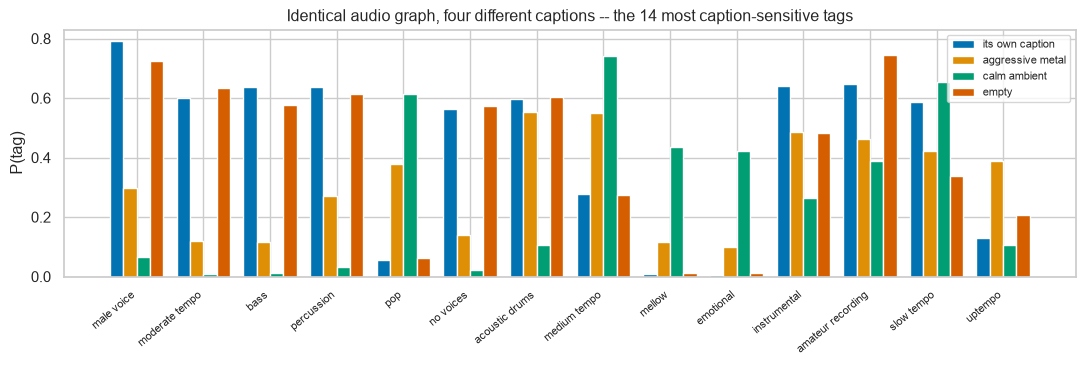

mean per-tag probability swing across the four captions: 0.2318
largest single swing: 0.7251 on 'male voice'


In [12]:
if fusion is not None:
    g0 = mc_test[7]
    own = text_masked[str(g0.track_id)]
    variants = {
        "its own caption": own,
        "aggressive metal": "A heavy distorted guitar track with double kick drums, loud and aggressive.",
        "calm ambient":     "A slow ambient piece with soft synthesiser pads, peaceful and spacious.",
        "empty":            "A music track.",
    }
    vmu, vsd = M["task3"]["valence_scale"]; amu, asd = M["task3"]["arousal_scale"]
    rows, probs = [], {}
    for name, txt in variants.items():
        o, _, _ = fuse(g0, txt)
        p = torch.sigmoid(o["tag_logits"])[0].cpu().numpy()
        probs[name] = p
        rows.append({"caption": name,
                     "valence": float(o["valence"]) * vsd + vmu,
                     "arousal": float(o["arousal"]) * asd + amu,
                     "top tags": ", ".join(np.array(tag_names)[np.argsort(p)[::-1][:4]])})
    display(pd.DataFrame(rows))

    P = np.stack([probs[k] for k in variants])
    keep = np.argsort(P.max(0) - P.min(0))[::-1][:14]          # most caption-sensitive tags
    fig, ax = plt.subplots(figsize=(11, 3.8))
    w = 0.2
    for i, name in enumerate(variants):
        ax.bar(np.arange(len(keep)) + i * w, probs[name][keep], w, label=name, color=PALETTE[i])
    ax.set_xticks(np.arange(len(keep)) + 1.5 * w)
    ax.set_xticklabels(np.array(tag_names)[keep], rotation=40, ha="right", fontsize=8)
    ax.set(ylabel="P(tag)", title="Identical audio graph, four different captions "
                                  "-- the 14 most caption-sensitive tags")
    ax.legend(fontsize=8); plt.tight_layout(); plt.show()

    swing = float((P.max(0) - P.min(0)).mean())
    print(f"mean per-tag probability swing across the four captions: {swing:.4f}")
    print(f"largest single swing: {float((P.max(0)-P.min(0)).max()):.4f} on "
          f"'{tag_names[int((P.max(0)-P.min(0)).argmax())]}'")

The swing number is the quantitative version of the claim. A near-zero swing would mean the
graph dominates and the text branch is ignored; a very large swing would mean the audio is
being ignored. The complement of this test is the `gnn_only` row of the Task 3 ablation
table, which is the same model with the text branch removed entirely.

---
## F. What this system gets wrong

Collected in one place, from `results/metrics.json`, so the limitations section of the
report is generated from measurements rather than recollection.

In [13]:
lim = []

if "task2" in M:
    best_gnn = max((v["test"]["macro_f1"] for k, v in M["task2"].items()
                    if k.startswith("gnn")), default=None)
    cnn = M["task2"].get("B2_mel_cnn", {}).get("test", {}).get("macro_f1")
    if best_gnn and cnn:
        lim.append(("Task 2", "graph features lose to raw spectrogram",
                    f"best GNN {best_gnn:.3f} vs mel-CNN {cnn:.3f} macro-F1"))
    sim = M["task2"].get("gnn_sage_similarity_only", {}).get("test", {}).get("macro_f1")
    full = M["task2"].get("gnn_sage_segment", {}).get("test", {}).get("macro_f1")
    if sim and full:
        lim.append(("Task 2", "temporal edges hurt",
                    f"similarity-only {sim:.3f} > full graph {full:.3f}"))

if "task1" in M:
    raw = M["task1"].get("B0_lexical_caption", {}).get("macro_f1")
    if raw:
        lim.append(("Task 1", "captions leak the labels",
                    f"regex on raw captions alone scores {raw:.3f} macro-F1"))

if "task3" in M:
    for k, v in M["task3"].items():
        if not k.startswith("task3_"):
            continue
        h = v.get("history") or []
        if len(h) >= 2 and h[-1].get("val_loss", 9e9) < h[-2].get("val_loss", 0):
            lim.append(("Task 3", f"{v['mode']} had not converged",
                        f"val loss still falling at final epoch {len(h)}"))

if "task4" in M:
    r10 = M["task4"]["test_retrieval"].get("R@10")
    n = int(M["task4"]["test_retrieval"]["n_candidates"])
    lim.append(("Task 4", "contrastive learning is data-starved",
                f"R@10 {r10:.4f} vs chance {10/n:.4f} over {n} candidates, "
                f"trained on only {M['task4']['n_train']} pairs"))

mani = ROOT / "data" / "raw" / "musiccaps_audio" / "manifest.json"
if mani.exists():
    mm = json.loads(mani.read_text(encoding="utf-8"))
    lim.append(("Data", "most MusicCaps audio is unrecoverable",
                f"{mm['total_wav_on_disk']}/{mm['nominal_clips']} clips "
                f"({100*mm['recovery_rate_vs_nominal']:.1f}%) -- the rest are deleted, "
                f"private, or behind YouTube's bot gate"))

display(pd.DataFrame(lim, columns=["where", "limitation", "evidence"]))

,where,limitation,evidence
0,Task 2,graph features lose to raw spectrogram,best GNN 0.500 vs mel-CNN 0.568 macro-F1
1,Task 2,temporal edges hurt,similarity-only 0.500 > full graph 0.341
2,Task 1,captions leak the labels,regex on raw captions alone scores 0.558 macro-F1
3,Task 3,gnn_only had not converged,val loss still falling at final epoch 6
4,Task 3,concat had not converged,val loss still falling at final epoch 6
5,Task 4,contrastive learning is data-starved,R@10 0.0510 vs chance 0.0129 over 775 candidat...
6,Data,most MusicCaps audio is unrecoverable,1657/5521 clips (30.0%) -- the rest are delete...


### Reading these together

The honest summary is that **the graph formulation is a net cost on genre classification and
an unproven benefit on fusion.** Segment-statistic nodes discard the time-frequency detail a
CNN uses, similarity edges carry real signal while temporal edges dilute it, and the
contrastive head never had the data volume its objective needs.

What the project does establish, and what a report can defend:

* The similarity/temporal edge ablation isolates *which* structure matters, which a
  monolithic audio model cannot answer at all.
* Masking the captions turns a 0.558 string-match into a genuine text task, and the
  before/after gap quantifies a contamination that published MusicCaps tagging numbers
  rarely control for.
* Cross-attention gives a directly inspectable audio-segment × word map (section C) — an
  interpretability handle that a concatenation-based fusion does not provide.

All figures in `results/plots/` and tables in `results/tables/` regenerate from the saved
predictions via `python scripts/evaluate.py`.

---
## G. Your own audio file

Every demo above reads a graph that `scripts/preprocess.py` already built and cached, and
then picks a clip out of a test split. That is the right way to *evaluate* — the splits are
what the metrics are defined over — but it means none of the sections above can answer
"what do these models say about a song of mine".

This section closes that gap. `scripts/predict.py` featurises an arbitrary audio file with
the same two functions the preprocessing pipeline uses, `extract_features` and
`build_segment_graph`, so the tensors reaching each checkpoint are distributed the way its
training data was. Set `AUDIO` below to any file `librosa` can read.

Three limits are structural rather than incidental, and they bound what the answer can be:

* Only the first `audio.clip_seconds` (30 s) is analysed. That is the window the models
  were trained on; reading further would change both the node count and the per-track
  normalisation statistics.
* Genre is GTZAN's ten classes and tags are the 50 most frequent MusicCaps aspects.
  Neither is open-vocabulary, so the model must answer from its list even when the right
  answer is not on it.
* Emotion returns to DEAM's original 1–9 valence/arousal scale, de-standardised with the
  training mean and standard deviation recorded in `metrics.json`.

In [14]:
from predict import featurise, predict_genre, predict_tags_emotion

# Point this at your own file. The fallbacks are the corpora this project already
# downloads, so the cell runs without extra setup -- but note that a GTZAN clip is
# *in* the Task 2 training domain and a DEAM clip is in Task 3's, so neither is a
# real out-of-domain test. Substitute something of your own for that.
AUDIO = None
CANDIDATES = [
    ROOT / "data" / "raw" / "genres" / "blues" / "blues.00012.wav",
    ROOT / "data" / "raw" / "deam_audio" / "MEMD_audio" / "1000.mp3",
]
audio = pathlib.Path(AUDIO) if AUDIO else next((p for p in CANDIDATES if p.exists()), None)

if audio is None:
    print("no audio file available -- set AUDIO to a path and re-run")
    gnew = None
else:
    tfnew, gnew, gstats = featurise(audio, cfg)
    print(f"file  : {audio.name}")
    print(f"audio : {gstats['seconds_used']:.1f} s analysed "
          f"(capped at {cfg.audio['clip_seconds']:.0f} s)")
    print(f"graph : {gstats['nodes']} nodes, {gstats['edges']} edges "
          f"({gstats['temporal_edges']} temporal, {gstats['similarity_edges']} similarity), "
          f"{gstats['node_dim']}-dim nodes")

    gp = predict_genre(cfg, M, tfnew, gnew, device, 3)
    print("\nGENRE -- GTZAN's 10 classes; chance is 0.100 macro-F1")
    for k, r in gp.items():
        top = "  |  ".join(f"{t} {v:.3f}" for t, v in r["top"])
        print(f"  {k:26s} [test macro-F1 {r['test_macro_f1']:.3f}]  {top}")

file  : blues.00012.wav
audio : 30.0 s analysed (capped at 30 s)
graph : 18 nodes, 42 edges (31 temporal, 11 similarity), 340-dim nodes

GENRE -- GTZAN's 10 classes; chance is 0.100 macro-F1
  B2_mel_cnn                 [test macro-F1 0.568]  blues 0.229  |  jazz 0.196  |  country 0.172
  gnn_sage_similarity_only   [test macro-F1 0.500]  jazz 0.643  |  hiphop 0.299  |  blues 0.026
  gnn_sage_segment           [test macro-F1 0.341]  blues 0.483  |  hiphop 0.188  |  reggae 0.137


The three genre models are all printed rather than just the best one, because they
disagree and the disagreement *is* the Task 2 result: the CNN on the raw spectrogram beats
both graph models, and deleting the temporal edges beats keeping them. A single number
here would hide that.

Below, the same clip goes through the Task 3 heads twice — once from audio alone
(`gnn_only`), once with a caption (`cross_attention`). The pair is the cleanest available
demonstration of what the text branch is actually worth, measured on a file that was not
in any split.

In [15]:
if gnew is not None:
    CAPTION = "a slow blues shuffle with a gritty electric guitar solo and a male singer"
    tp = predict_tags_emotion(cfg, M, gnew, device, CAPTION, 5)
    rows = []
    for mode, r in tp.items():
        rows.append({"head": mode,
                     "input": "audio + caption" if r["used_caption"] else "audio only",
                     "valence": r["valence"], "arousal": r["arousal"],
                     "quadrant": r["quadrant"],
                     "tags > thr": f"{r['n_above_threshold']}/50",
                     "test tag F1": r["test_tag_macro_f1"],
                     "top tags": ", ".join(t for t, _ in r["top_tags"][:4])})
    display(pd.DataFrame(rows))

    for mode, r in tp.items():
        print(f"\n{mode}: " + "  ".join(f"{t} {v:.3f}" for t, v in r["top_tags"]))

,head,input,valence,arousal,quadrant,tags > thr,test tag F1,top tags
0,gnn_only,audio only,4.297,4.131,sad/depressed,22/50,0.112867,"slow tempo, emotional, passionate, instrumental"
1,cross_attention,audio + caption,3.749,3.825,sad/depressed,4/50,0.305541,"slow tempo, medium tempo, emotional, romantic"



gnn_only: slow tempo 0.591  emotional 0.562  passionate 0.554  instrumental 0.524  noisy 0.517

cross_attention: slow tempo 0.805  medium tempo 0.760  emotional 0.628  romantic 0.618  pop 0.568


Read the `tags > thr` column together with `test tag F1`. `gnn_only` fires on a large
fraction of the vocabulary because its tuned threshold sits at 0.30 with macro-precision
0.064 — from audio alone the model is close to guessing, and the honest reading of its tag
row is that it has learned tag *frequency*, not tag identity. `cross_attention` clears the
threshold on a handful of tags instead, at nearly three times the macro-F1.

The emotion columns move the other way, and that asymmetry is the project's clearest
positive finding: valence and arousal are properties of the audio that a caption rarely
states outright, so the graph contributes there (arousal R² 0.42 → 0.54) even though it
contributes nothing measurable to tags.

`scripts/predict.py` is the same code as a command line, with `--json` for a
machine-readable dump:

```bash
python scripts/predict.py mysong.mp3 --caption "a mellow jazz trio with brushed drums"
```